# STBSR example: DLPFC 151671

This notebook runs one complete STBSR training on the bundled 151671 example and displays the resulting spatial domains. It does not write CSV, h5ad, or PNG files.

In [1]:
from pathlib import Path
from contextlib import redirect_stdout
from functools import partial
import io
import sys
import warnings

import matplotlib.pyplot as plt
from IPython.display import Image, display
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=r"pkg_resources is deprecated as an API.*",
        category=UserWarning,
    )
    import scanpy as sc
from tqdm import tqdm as text_tqdm

ROOT = Path.cwd().resolve()
if not (ROOT / "STBSR").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "STBSR").is_dir():
    raise FileNotFoundError("Run this notebook from the stbsr_code repository.")
sys.path.insert(0, str(ROOT))

from STBSR import pipeline as stbsr

DATASET = "151671"
DATA_DIR = ROOT / "example_data" / DATASET
EPOCHS = 500
SEED = 1
SPATIAL_RADIUS = 560
PLOT_SPOT_SIZE = 100.0

if not DATA_DIR.is_dir():
    raise FileNotFoundError(DATA_DIR)

stbsr.DLPFC_PATHS = {DATASET: str(DATA_DIR)}
stbsr.DLPFC_TARGET_COL = "layer_guess_reordered"
stbsr.EPOCHS = EPOCHS
stbsr.SPATIAL_RADIUS_BY_DATASET[DATASET] = SPATIAL_RADIUS
stbsr.PLOT_SPOT_SIZE_BY_DATASET[DATASET] = PLOT_SPOT_SIZE

stbsr.tqdm = partial(text_tqdm, mininterval=1.0)

## Run STBSR

In [2]:
training_log = io.StringIO()
with redirect_stdout(training_log):
    adata, n_class, _ = stbsr.load_dataset(DATASET)
    adata = stbsr.normalize_adata(adata, highly_genes=stbsr.highly_genes)
    adata = stbsr.precluster(adata, n_class, dataset_name=DATASET)
    stbsr.set_seed(SEED)
    metrics = stbsr.train_model(
        adata,
        n_class,
        DATASET,
        SEED,
        stbsr.GAMMA,
    )

Epoch: 100%|██████████████████████████████████| 500/500 [00:37<00:00, 13.29it/s]


## Spatial-domain result

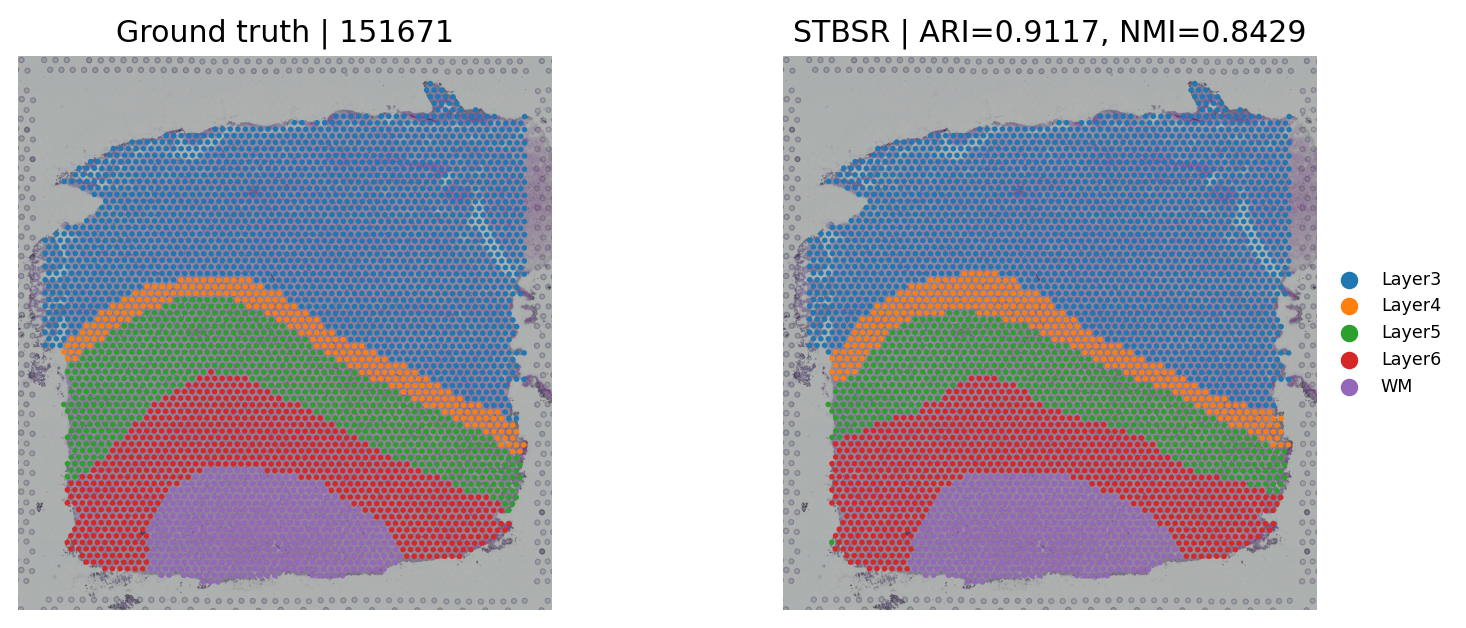

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=r"Use `squidpy\.pl\.spatial_scatter` instead\.",
        category=FutureWarning,
    )
    sc.pl.spatial(
        adata,
        color="ground_truth",
        spot_size=PLOT_SPOT_SIZE,
        legend_loc=None,
        title=f"Ground truth | {DATASET}",
        ax=axes[0],
        show=False,
    )
    sc.pl.spatial(
        adata,
        color="cluster_final_plot",
        spot_size=PLOT_SPOT_SIZE,
        legend_loc="right margin",
        legend_fontsize=7,
        title=(
            f"STBSR | "
            f"ARI={metrics['ARI']:.4f}, NMI={metrics['NMI']:.4f}"
        ),
        ax=axes[1],
        show=False,
    )
for axis in axes:
    axis.set_axis_off()
plt.subplots_adjust(wspace=0.25, right=0.82)
image_buffer = io.BytesIO()
fig.savefig(image_buffer, format="png", dpi=180, bbox_inches="tight")
display(Image(data=image_buffer.getvalue()))
plt.close(fig)